# <font color=blue>Proyecto de Minería de Datos — Hito 2</font>
## **Preparación de Datos y Primera Matriz Analítica**
**Docente:** Soledad Espezúa Llerena  
**Equipo de Investigación (Grupo Data Hunters):**
- Fernando Torres
- Romy Tipacti
- Arturo Alvarez  

**Institución:** Universidad del Pacífico  
**Semestre Académico:** 2026-II  

---

### **Objetivo del Cuaderno:**
Desarrollar el flujo sistemático de preparación de datos, diagnóstico de calidad, corrección de granularidad e ingeniería de características para construir la **primera matriz analítica** a nivel de proyecto individual (**CUI**), integrando las fuentes oficiales del Ministerio de Economía y Finanzas (**Seguimiento_PI** y **Proceso_Seleccion**).


---
# <font color=navy>1. Marco de Trabajo y Ajustes Metodológicos desde el Hito 1</font>
### *Alineación de objetivos y transición hacia la unidad de análisis a nivel de proyecto (CUI)*

### **1.1. Reformulación del Problema Aplicado y Justificación de Negocio**
El Sistema Nacional de Programación Multianual y Gestión de Inversiones (**Invierte.pe**) asigna anualmente decenas de miles de millones de soles al desarrollo de infraestructura pública. Sin embargo, en la gestión pública coexisten dos sistemas desintegrados del Ministerio de Economía y Finanzas (MEF):
1. **`Seguimiento_PI` (MEF):** Registra la ejecución presupuestal y financiera (cuánto dinero se certifica, devenga y gira).
2. **`Proceso_Seleccion` (MEF):** Registra los procesos de contratación, licitaciones y las valorizaciones periódicas del avance físico de obra en terreno.

**La problemática crítica:** La falta de cruce y conciliación periódica entre ambas fuentes impide detectar oportunamente un patrón recurrente de ineficiencia y alto riesgo fiscal: **proyectos de inversión con gasto financiero acelerado que no se traduce en avance físico real** (por ejemplo, obras con más del 80% de ejecución presupuestal pero apenas 20% o 30% de avance físico certificado). Este descalce es el síntoma precursor de sobrecostos presupuestales, adendas contractuales, arbitrajes y paralización de obras (*"elefantes blancos"*).

---

### **1.2. Corrección Estructural de Granularidad: De la Partida Anual al Proyecto CUI**
En la evaluación diagnóstica del Hito 1, los datos se encontraban a nivel transaccional y con excesiva dispersión temporal, generando una relación muchos a muchos ($N:M$) que distorsionaba el modelado:
- **`Seguimiento_PI` crudo (696,688 filas):** Granularidad a nivel de partida anual por pliego, meta presupuestal y clasificador de gasto. Un mismo proyecto aparecía registrado hasta 15 veces (una fila por cada año fiscal ejecutado).
- **`Proceso_Seleccion` crudo (5,672,274 filas):** Granularidad a nivel de ítem licitado, contrato o valorización mensual. Un mismo proyecto registraba decenas de filas por cada proceso contractual.

**La Corrección Metodológica:**
Para aplicar algoritmos de Minería de Datos (clustering de tipologías, perfiles de ejecución y detección de anomalías), cada fila de la matriz debe representar una **unidad de decisión autónoma y comparable**. Por tanto, redefinimos estrictamente la unidad de análisis:
$$\mathbf{1\text{ fila}} = \mathbf{1\text{ Proyecto de Inversión Pública (CUI)}}$$

| Dimensión Metodológica | Enfoque Hito 1 (Transaccional) | Enfoque Corregido Hito 2 (Unidad Proyecto CUI) | Justificación Técnica |
|:---|:---|:---|:---|
| **Unidad de Análisis** | Transacción presupuestal anual / Contrato | **Proyecto de Inversión Pública (CUI)** | Permite modelar el ciclo de vida completo de cada obra sin duplicidades temporales. |
| **Granularidad `Seguimiento_PI`** | 696,688 registros anuales | **52,480 proyectos consolidados** | Agregación `groupby(CUI)` sumando gasto histórico devengado y tiempo de maduración. |
| **Granularidad `Proceso_Seleccion`** | 5,672,274 registros contractuales | **46,742 proyectos consolidados** | Consolidación `groupby(CUI)` con el último avance físico certificado y montos adjudicados. |
| **Tratamiento de Ruido** | Códigos genéricos incluidos | **197 códigos genéricos excluidos** | Se retiraron bolsas presupuestales compartidas por miles de entidades (como `2001621` de preinversión). |
| **Tipo de Integración** | Exploratoria / dispersa | **Left Join 1 a 1 determinístico** | Integración relacional limpia auditada con `validate='one_to_one'`. |

---

### **1.3. Cascada de Delimitación del Universo Analítico (Población Objetivo)**
El alcance del problema y la población de estudio se acota de forma rigurosa, justificada y reproducible:
1. **52,480 proyectos CUI** componen el portafolio presupuestal real del MEF (tras excluir bolsas genéricas de gasto corriente).
2. **35,472 proyectos CUI (67.59%)** cruzan exitosamente con `Proceso_Seleccion` (`both`), registrando asignación presupuestal y procesos contractuales. (Los 17,008 restantes en `left_only` corresponden a obras ejecutadas por *Administración Directa* con maquinaria y personal propio de la entidad, o compras directas < 8 UIT).
3. **1,978 proyectos CUI en Ejecución Activa (Universo Analítico de la Matriz):** De los 35,472 proyectos coincidentes, seleccionamos aquellos que poseen **reporte simultáneo de avance físico de obra válido y ejecución de gasto devengado real**.
   - *¿Por qué este filtro es indispensable?* En proyectos sin reporte de avance físico (compras de bienes/servicios o proyectos archivados), la variable objetivo central—la **Brecha Gasto - Avance**—no existe ni puede imputarse arbitrariamente sin falsear la auditoría.
   - Por ende, nuestro problema queda delimitado al **portafolio de obras de infraestructura pública activa con supervisión reportada**, garantizando que el 100% de los datos en la matriz analítica reflejen obras reales con métricas auditables.

---

### **1.4. Objetivo Analítico y Preguntas Clave de Minería de Datos**
- **Objetivo Principal:** Segmentar y perfilar el portafolio de obras públicas activas para identificar conglomerados con desfase crítico financiero-físico y detectar anomalías en la velocidad de ejecución presupuestal.
- **Preguntas de Negocio que responde la matriz:**
  1. ¿Qué características estructurales (nivel de gobierno, tamaño de inversión, años de maduración) concentran el mayor porcentaje de obras con gasto adelantado al avance físico?
  2. ¿Cuáles son los proyectos atípicos extremos (anomalías) que requieren auditoría prioritaria por parte de la Contraloría General de la República?


---
# <font color=green>1. Configuración de librerías y entorno de trabajo</font>

Comenzamos importando las librerías estándar para análisis de datos, visualización y preparación de matrices numéricas, configurando un estilo simple y legible para los gráficos.


In [1]:
# Cargamos las librerías necesarias para el análisis
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Configuramos un estilo base limpio para los gráficos (igual al laboratorio de clase)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams.update({"figure.autolayout": True})


---
# <font color=green>2. Carga y exploración inicial de las fuentes de datos</font>

Cargamos los dos archivos CSV oficiales del Ministerio de Economía y Finanzas (MEF):
- **`Seguimiento_PI.csv`**: Asignación presupuestal y gasto devengado histórico registrado a través del SIAF y Banco de Inversiones.
- **`Proceso_Seleccion.csv`**: Historial de procesos de contratación, compras públicas y valorizaciones del avance físico de obras reportado por los supervisores.


In [2]:
# Cargamos las dos fuentes de datos oficiales del MEF
seguimiento = pd.read_csv("Seguimiento_PI.csv", low_memory=False)
proceso = pd.read_csv("Proceso_Seleccion.csv", low_memory=False)

# Observamos las dimensiones iniciales
print("Dimensiones Seguimiento_PI:", seguimiento.shape)
print("Dimensiones Proceso_Seleccion:", proceso.shape)

# Revisamos las primeras filas de Seguimiento_PI
print("\nPrimeras filas de Seguimiento_PI:")
display(seguimiento.head(3))

# Revisamos las primeras filas de Proceso_Seleccion
print("\nPrimeras filas de Proceso_Seleccion:")
display(proceso.head(3))


Dimensiones Seguimiento_PI: (696688, 35)
Dimensiones Proceso_Seleccion: (5672274, 14)

Primeras filas de Seguimiento_PI:


,ANO_EJE,NIVEL_GOBIERNO,NIVEL_GOBIERNO_NOMBRE,SECTOR,SECTOR_NOMBRE,PLIEGO,PLIEGO_NOMBRE,SEC_EJEC,EJECUTORA,EJECUTORA_NOMBRE,DEPARTAMENTO_EJECUTORA,DEPARTAMENTO_EJECUTORA_NOMBRE,PROVINCIA_EJECUTORA,PROVINCIA_EJECUTORA_NOMBRE,DISTRITO_EJECUTORA,DISTRITO_EJECUTORA_NOMBRE,TIPO_ACT_PROY,TIPO_ACT_PROY_NOMBRE,PRODUCTO_PROYECTO,PRODUCTO_PROYECTO_NOMBRE,FUNCION,FUNCION_NOMBRE,DEPARTAMENTO_META,DEPARTAMENTO_META_NOMBRE,FUENTE_FINANCIAMIENTO,FUENTE_FINANCIAMIENTO_NOMBRE,RUBRO,RUBRO_NOMBRE,COSTO_ACTUAL,MONTO_EJECUCION_HASTA_HACE_2_ANOS,MONTO_EJECUCION_ANO_ANTERIOR,MONTO_PIA,MONTO_PIM,MONTO_DEVENGADO_ANO_EJE,MONTO_EJECUCION_TOTAL
0,2005,R,GOBIERNOS REGIONALES,99,GOBIERNOS REGIONALES,460,GOBIERNO REGIONAL TACNA,931,1,REGION TACNA-SEDE CENTRAL,23,TACNA,1,TACNA,1,REGION TACNA-SEDE CENTRAL,2,PROYECTO,2015918,PROYECTO VIAL TACNA LA PAZ,16,TRANSPORTE,23,TACNA,1,RECURSOS ORDINARIOS,15,FONDO DE COMPENSACION REGIONAL,0.0,97546.66,0.0,0,0,0.0,97546.66
1,2005,R,GOBIERNOS REGIONALES,99,GOBIERNOS REGIONALES,460,GOBIERNO REGIONAL TACNA,1210,2,REGION TACNA - PROY. ESP. RECURSOS HIDRICOS TACNA,0,,0,,0,,2,PROYECTO,2000351,OPERACION Y MANTENIMIENTO,4,AGRARIA,23,TACNA,2,RECURSOS DIRECTAMENTE RECAUDADOS,9,RECURSOS DIRECTAMENTE RECAUDADOS,0.0,1617683.93,0.0,0,0,0.0,1617683.93
2,2005,R,GOBIERNOS REGIONALES,99,GOBIERNOS REGIONALES,448,GOBIERNO REGIONAL HUANUCO,804,1,REGION HUANUCO-SEDE CENTRAL,10,HUANUCO,1,HUANUCO,2,REGION HUANUCO-SEDE CENTRAL,2,PROYECTO,2001707,LIQUIDACION DE OBRAS,9,EDUCACION Y CULTURA,10,HUANUCO,1,RECURSOS ORDINARIOS,15,FONDO DE COMPENSACION REGIONAL,0.0,174390.21,0.0,0,0,0.0,174390.21



Primeras filas de Proceso_Seleccion:


,CODIGO_UNICO,DES_PRODUCTO,DES_ACCION,DES_TIPO_COMPONENTE,DES_UM_PRODU,VAL_META_PRODU,DES_UM_CAPAC,VAL_META_CAPAC,COSTO_INVERSION,PERIODO,VALORIZ_ACUM,AVANCE,DES_OBSERVACIONES,DES_ETAPA
0,2318999,Producto 1: LABORES MINERAS SUBTERRANEAS TRATADAS Y CERRADAS,Cierre con Tapón hermético Bocaminas,INFRAESTRUCTURA,ESPACIOS FISICOS,43.28,M3,"43,28",455417.95,2019-08,455417.95,NaN,NaN,CONTRACTUAL
1,2318999,Producto 1: LABORES MINERAS SUBTERRANEAS TRATADAS Y CERRADAS,Cierre con Tapón hermético Bocaminas,INFRAESTRUCTURA,ESPACIOS FISICOS,43.28,M3,"43,28",455417.95,IV-2017,331867.00,NaN,NaN,EJECUCION
2,2318999,Producto 1: LABORES MINERAS SUBTERRANEAS TRATADAS Y CERRADAS,Cierre con Tapón hermético Bocaminas,INFRAESTRUCTURA,ESPACIOS FISICOS,43.28,M3,"43,28",455417.95,IV-2017,503436.58,NaN,NaN,CRONOGRAMA


---
# <font color=green>3. Diagnóstico básico de calidad</font>

Siguiendo la metodología trabajada en clase, creamos un diccionario de tablas para inspeccionar de manera sistemática:
1. Conteo de filas duplicadas exactas.
2. Detección de filas completamente vacías.
3. Detección de columnas completamente vacías.
4. Identificación de columnas con datos faltantes (`NaN`).


In [3]:
# Agrupamos las tablas en un diccionario para diagnosticarlas con el formato de clase
tablas = {
    "Seguimiento_PI": seguimiento,
    "Proceso_Seleccion": proceso
}

for nombre, df in tablas.items():
    print(f"\n--- Diagnóstico de calidad: {nombre} ---")

    # Excluimos las filas totalmente vacías antes de contar duplicados (criterio de clase)
    no_vacias = df.loc[~df.isna().all(axis=1)]

    print("Duplicados exactos:", no_vacias.duplicated().sum())
    print("Filas completamente vacías:", df.isna().all(axis=1).sum())
    print("Columnas completamente vacías:", df.columns[df.isna().all(axis=0)].tolist())

    faltantes = df.isna().sum()
    print("Columnas con faltantes:")
    print(faltantes[faltantes > 0])



--- Diagnóstico de calidad: Seguimiento_PI ---
Duplicados exactos: 0
Filas completamente vacías: 0
Columnas completamente vacías: []
Columnas con faltantes:
Series([], )

--- Diagnóstico de calidad: Proceso_Seleccion ---
Duplicados exactos: 113081
Filas completamente vacías: 0
Columnas completamente vacías: []
Columnas con faltantes:
DES_PRODUCTO             96074
DES_ACCION              585703
DES_TIPO_COMPONENTE     490675
DES_UM_PRODU           1464212
VAL_META_PRODU         1177544
DES_UM_CAPAC           2791006
VAL_META_CAPAC         1450097
COSTO_INVERSION            510
PERIODO                1418376
VALORIZ_ACUM           4334993
AVANCE                 5078775
DES_OBSERVACIONES      3344533


**Interpretación:**
- En **`Seguimiento_PI`** no existen duplicados exactos ni columnas vacías. Cada registro representa una partida presupuestal asignada a un proyecto en un año específico.
- En **`Proceso_Seleccion`** se detectan **113,081 duplicados exactos**, que corresponden a retransmisiones automáticas del sistema de compras públicas. Además, las columnas `AVANCE` y `PERIODO` registran una proporción importante de faltantes, lo cual es coherente porque no todos los procesos de selección son obras físicas en ejecución.


---
# <font color=green>4. Limpieza inicial</font>

Definimos la función `limpieza_inicial()` vista en clase para eliminar duplicados exactos y descartar filas o columnas completamente vacías, garantizando bases estructuralmente limpias antes de cualquier análisis.


In [4]:
# Definimos la función de limpieza inicial trabajada en clase
def limpieza_inicial(df):
    # Elimina duplicados exactos.
    df = df.drop_duplicates()

    # Elimina únicamente filas donde TODAS las columnas están vacías.
    df = df.dropna(how="all")

    # Elimina únicamente columnas completamente vacías.
    df = df.dropna(axis=1, how="all")

    return df.copy()

# Aplicamos la limpieza a ambas tablas
seguimiento = limpieza_inicial(seguimiento)
proceso = limpieza_inicial(proceso)

print("Dimensiones después de la limpieza inicial:")
print("Seguimiento_PI:", seguimiento.shape)
print("Proceso_Seleccion:", proceso.shape)


Dimensiones después de la limpieza inicial:
Seguimiento_PI: (696688, 35)
Proceso_Seleccion: (5559193, 14)


---
# <font color=green>5. Relaciones y claves antes del `merge()`</font>

Antes de intentar cualquier cruce relacional, verificamos si la clave de integración (`codigo_proyecto`) es única en cada una de las tablas originales.


In [5]:
# Verificamos si la clave es única en las tablas originales
print("¿PRODUCTO_PROYECTO es único en Seguimiento_PI?:", seguimiento["PRODUCTO_PROYECTO"].is_unique)
print("¿CODIGO_UNICO es único en Proceso_Seleccion?:", proceso["CODIGO_UNICO"].is_unique)


¿PRODUCTO_PROYECTO es único en Seguimiento_PI?: False
¿CODIGO_UNICO es único en Proceso_Seleccion?: False


## <font color=d00000>¿Qué ocurre si integramos Seguimiento_PI y Proceso_Seleccion directamente?</font>

**Interpretación:** Ninguna de las dos claves es única en su fuente original.  
- En `Seguimiento_PI`, un mismo proyecto se repite tantas veces como años fiscales ha tenido ejecución presupuestal.  
- En `Proceso_Seleccion`, un mismo proyecto se repite tantas veces como procesos de licitación, contratos o valorizaciones mensuales ha registrado.

Si realizáramos un `merge()` directo sin agregar, obtendríamos una **relación Muchos a Muchos ($N:M$)**, lo que provocaría una explosión de filas artificiales y duplicaría montos presupuestales.  
Para conservar la unidad **1 fila = 1 Proyecto de Inversión Pública (CUI)**, debemos llevar primero cada tabla a esa misma granularidad mediante `groupby()`.


---
# <font color=green>6. Tratamiento de códigos presupuestales genéricos</font>

Un proyecto de inversión real (CUI) tiene una única entidad ejecutora (o a lo sumo un convenio de cofinanciamiento con 2 o 3).  
Sin embargo, en `Seguimiento_PI` detectamos códigos utilizados por decenas o miles de municipalidades independientes (ej. código `2001621` *"Estudios de Preinversión"*, usado por 2,384 entidades). Estos representan **bolsas presupuestales genéricas de gasto corriente** que no corresponden a una obra física individualizada con contratista externo. Procedemos a identificarlos y excluirlos.


In [6]:
# Identificamos códigos presupuestales registrados por más de 5 entidades ejecutoras independientes
ejecutoras_por_codigo = seguimiento.groupby("PRODUCTO_PROYECTO")["EJECUTORA_NOMBRE"].nunique()
codigos_genericos = ejecutoras_por_codigo[ejecutoras_por_codigo > 5].index

print("Códigos genéricos encontrados (> 5 ejecutoras):", len(codigos_genericos))
print("Filas de códigos genéricos excluidas en Seguimiento_PI:", seguimiento["PRODUCTO_PROYECTO"].isin(codigos_genericos).sum())

# Filtramos Seguimiento_PI para conservar únicamente proyectos de inversión reales
seg_reales = seguimiento[~seguimiento["PRODUCTO_PROYECTO"].isin(codigos_genericos)].copy()
print("Proyectos CUI reales únicos en Seguimiento_PI:", seg_reales["PRODUCTO_PROYECTO"].nunique())


Códigos genéricos encontrados (> 5 ejecutoras): 197
Filas de códigos genéricos excluidas en Seguimiento_PI: 479,015
Proyectos CUI reales únicos en Seguimiento_PI: 52,480


---
# <font color=green>7. `groupby()` para cambiar la granularidad en `Seguimiento_PI`</font>

Para conservar una fila por proyecto CUI, resumimos el historial anual de `Seguimiento_PI`:
- Sumamos el PIM y el devengado histórico.
- Tomamos el costo de inversión actualizado y el gasto acumulado máximo.
- Calculamos el año de inicio, año de fin y el número de registros presupuestales del proyecto.


In [7]:
# Agrupamos Seguimiento_PI a nivel estricto de 1 fila = 1 Proyecto CUI
seg_cui = (
    seg_reales.groupby("PRODUCTO_PROYECTO")
    .agg(
        nombre_proyecto=("PRODUCTO_PROYECTO_NOMBRE", "first"),
        nivel_gobierno=("NIVEL_GOBIERNO_NOMBRE", "first"),
        sector=("SECTOR_NOMBRE", "first"),
        departamento=("DEPARTAMENTO_EJECUTORA_NOMBRE", "first"),
        costo_actual=("COSTO_ACTUAL", "max"),
        pim_acumulado=("MONTO_PIM", "sum"),
        devengado_acumulado=("MONTO_DEVENGADO_ANO_EJE", "sum"),
        gasto_total=("MONTO_EJECUCION_TOTAL", "max"),
        anio_inicio=("ANO_EJE", "min"),
        anio_fin=("ANO_EJE", "max"),
        n_registros_presupuesto=("ANO_EJE", "count")
    )
    .reset_index()
    .rename(columns={"PRODUCTO_PROYECTO": "codigo_proyecto"})
)

print("Seguimiento_PI consolidado a nivel proyecto CUI:", seg_cui.shape)
print("¿La clave codigo_proyecto es única en seg_cui?:", seg_cui["codigo_proyecto"].is_unique)
display(seg_cui.head(3))


Seguimiento_PI consolidado a nivel proyecto CUI: (52480, 12)
¿La clave codigo_proyecto es única en seg_cui?: True


,codigo_proyecto,nombre_proyecto,nivel_gobierno,sector,departamento,costo_actual,pim_acumulado,devengado_acumulado,gasto_total,anio_inicio,anio_fin,n_registros_presupuesto
0,2000846,PEQUEÑO SISTEMA ELECTRICO CHILETE III ETAPA,GOBIERNOS REGIONALES,GOBIERNOS REGIONALES,CAJAMARCA,1.127529e+07,64469,64468.80,3.540670e+06,2006,2026,18
1,2001706,LINEA DE TRANSMISION 60 KV CHICLAYO - BOCA DE SALIDA DEL TUNEL TRASANDINO,GOBIERNOS REGIONALES,GOBIERNOS REGIONALES,LAMBAYEQUE,0.000000e+00,1483213,521088.36,2.109734e+06,2005,2026,24
2,2002060,REHABILITACION Y MEJORAMIENTO DE CARRETERA TINGO MARIA - AGUAYTIA - PUCALLPA,GOBIERNO NACIONAL,TRANSPORTES Y COMUNICACIONES,LIMA,1.288154e+09,117896,66509.60,1.852216e+08,2005,2026,39


---
# <font color=green>8. `groupby()` para cambiar la granularidad en `Proceso_Seleccion`</font>

Antes de resumir `Proceso_Seleccion`, corregimos inconsistencias de dominio (porcentajes de avance fuera de $[0, 100]\%$ y costos $\le 0$). Luego, ordenamos cronológicamente y rescatamos el **último avance físico certificado** de cada obra.


In [8]:
# Limpiamos inconsistencias de rango antes de agregar
proceso["AVANCE"] = pd.to_numeric(proceso["AVANCE"], errors="coerce")
proceso.loc[(proceso["AVANCE"] < 0) | (proceso["AVANCE"] > 100), "AVANCE"] = np.nan

proceso["COSTO_INVERSION"] = pd.to_numeric(proceso["COSTO_INVERSION"], errors="coerce")
proceso.loc[proceso["COSTO_INVERSION"] <= 0, "COSTO_INVERSION"] = np.nan

# Ordenamos cronológicamente por periodo de reporte
proceso = proceso.sort_values(by=["CODIGO_UNICO", "PERIODO"])

# Resumimos Proceso_Seleccion a nivel de proyecto CUI
proc_cui = (
    proceso.groupby("CODIGO_UNICO")
    .agg(
        costo_inversion=("COSTO_INVERSION", "max"),
        etapa_proyecto=("DES_ETAPA", "last"),
        n_contratos=("CODIGO_UNICO", "count")
    )
    .reset_index()
    .rename(columns={"CODIGO_UNICO": "codigo_proyecto"})
)

# Rescatamos el último avance físico válido no nulo de cada obra
proc_con_avance = proceso[proceso["AVANCE"].notna()]
ultimo_avance = proc_con_avance.groupby("CODIGO_UNICO")["AVANCE"].last()
proc_cui["avance_fisico_pct"] = proc_cui["codigo_proyecto"].map(ultimo_avance)

print("Proceso_Seleccion consolidado a nivel proyecto CUI:", proc_cui.shape)
print("¿La clave codigo_proyecto es única en proc_cui?:", proc_cui["codigo_proyecto"].is_unique)
display(proc_cui.head(3))


Proceso_Seleccion consolidado a nivel proyecto CUI: (204162, 5)
¿La clave codigo_proyecto es única en proc_cui?: True


,codigo_proyecto,costo_inversion,etapa_proyecto,n_contratos,avance_fisico_pct
0,2000680,3335613.13,CONSISTENCIA,1,NaN
1,2000846,4492959.17,CONSISTENCIA,30,NaN
2,2001019,615521.52,CONSISTENCIA,2,NaN


---
# <font color=green>9. Integración relacional determinística (Left Join 1 a 1)</font>

En un **left merge**, colocamos a la izquierda la tabla cuya unidad de análisis queremos conservar (`Seguimiento_PI` como portafolio maestro de proyectos de inversión). Usamos `validate="one_to_one"` para asegurar que la relación entre claves sea estrictamente unívoca.


In [9]:
# Unimos las dos tablas consolidadas mediante left join 1 a 1
base_integrada = seg_cui.merge(
    proc_cui,
    on="codigo_proyecto",
    how="left",
    validate="one_to_one",
    indicator="origen_cruce"
)

# Revisamos los resultados del cruce con indicator=True
print("=== RESULTADO DEL CRUCE (Seguimiento_PI vs Proceso_Seleccion) ===")
print(base_integrada["origen_cruce"].value_counts())
print("\nDimensiones de base_integrada:", base_integrada.shape)
print("¿La clave codigo_proyecto es única en base_integrada?:", base_integrada["codigo_proyecto"].is_unique)

display(base_integrada[["codigo_proyecto", "nombre_proyecto", "nivel_gobierno", "costo_actual", "costo_inversion", "avance_fisico_pct", "origen_cruce"]].head(3))


=== RESULTADO DEL CRUCE (Seguimiento_PI vs Proceso_Seleccion) ===
origen_cruce
both          35472
left_only     17008
right_only        0

Dimensiones de base_integrada: (52480, 17)
¿La clave codigo_proyecto es única en base_integrada?: True


,codigo_proyecto,nombre_proyecto,nivel_gobierno,costo_actual,costo_inversion,avance_fisico_pct,origen_cruce
0,2000846,PEQUEÑO SISTEMA ELECTRICO CHILETE III ETAPA,GOBIERNOS REGIONALES,1.127529e+07,4.492959e+06,NaN,both
1,2001706,LINEA DE TRANSMISION 60 KV CHICLAYO - BOCA DE SALIDA DEL TUNEL TRASANDINO,GOBIERNOS REGIONALES,0.000000e+00,NaN,NaN,left_only
2,2002060,REHABILITACION Y MEJORAMIENTO DE CARRETERA TINGO MARIA - AGUAYTIA - PUCALLPA,GOBIERNO NACIONAL,1.288154e+09,2.635171e+08,100.0,both


**Interpretación del cruce:**
- **35,472 proyectos (67.59%) coinciden en ambas fuentes (`both`)**: disponen tanto de asignación presupuestal registrada en `Seguimiento_PI` como de historial de contrataciones en `Proceso_Seleccion`.
- **17,008 proyectos (32.41%) aparecen únicamente en `Seguimiento_PI` (`left_only`)**: corresponden a proyectos ejecutados bajo la modalidad de **Administración Directa** (la entidad ejecuta con su propio personal y maquinaria sin contratar a terceros), compras directas menores a 8 UIT o proyectos en etapas preliminares que no requieren proceso licitatorio externo.


---
# <font color=green>10. Delimitación del universo de modelado: Cascada de granularidad</font>

Para realizar Minería de Datos y calcular la **Brecha Gasto - Avance**, necesitamos que el proyecto tenga información concurrente tanto de avance físico en obra como de gasto presupuestal devengado.  
Aplicamos el principio de clase: *"detectar faltantes no significa imputar por imputar"*. Imputar una mediana o media de avance físico a proyectos sin obra crearía distorsiones graves en la auditoría.


In [10]:
# Mostramos la cascada formal de datos desde las fuentes crudas hasta el universo de modelado
print("=== CASCADA DE DELIMITACIÓN DE GRANULARIDAD ===")
print("1. Total proyectos en Seguimiento_PI (CUI): 52,480 (100.0%)")
print("2. Proyectos coincidentes con Proceso_Seleccion (both): 35,472 (67.6%)")
print("3. Proyectos por Administración Directa (left_only): 17,008 (32.4%)")
print("4. Proyectos en ejecución activa con avance físico y gasto real: 1,978 (Universo Matriz Analítica)")

# Filtramos los proyectos en ejecución activa con avance físico y gasto real
filtro = (
    (base_integrada["origen_cruce"] == "both") &
    (base_integrada["avance_fisico_pct"].notna()) &
    (base_integrada["costo_inversion"] > 0) &
    (base_integrada["gasto_total"] > 0)
)
df_eda = base_integrada[filtro].copy()

# Calculamos variables preliminares para la exploración visual
df_eda["pct_ejecucion"] = (df_eda["gasto_total"] / df_eda["costo_inversion"]) * 100
df_eda["brecha"] = df_eda["pct_ejecucion"] - df_eda["avance_fisico_pct"]
df_eda["alerta"] = (df_eda["brecha"] > 15.0).astype(int)

print(f"\nProyectos activos seleccionados para el análisis: {len(df_eda):,}")


=== CASCADA DE DELIMITACIÓN DE GRANULARIDAD ===
1. Total proyectos en Seguimiento_PI (CUI): 52,480 (100.0%)
2. Proyectos coincidentes con Proceso_Seleccion (both): 35,472 (67.6%)
3. Proyectos por Administración Directa (left_only): 17,008 (32.4%)
4. Proyectos en ejecución activa con avance físico y gasto real: 1,978 (Universo Matriz Analítica)

Proyectos activos seleccionados para el análisis: 1,978


---
# <font color=green>11. Detección de valores atípicos (Regla IQR vs. Z-Score)</font>

Siguiendo el esquema de la sesión de calidad de datos, comparamos formalmente los dos métodos de detección de outliers sobre la variable cuantitativa `costo_inversion`.


In [11]:
# Evaluamos valores atípicos en el costo de inversión
# 1. Regla del Rango Intercuartílico (IQR)
q1 = df_eda["costo_inversion"].quantile(0.25)
q3 = df_eda["costo_inversion"].quantile(0.75)
iqr = q3 - q1
lim_inf = q1 - 1.5 * iqr
lim_sup = q3 + 1.5 * iqr
atipicos_iqr = df_eda[(df_eda["costo_inversion"] < lim_inf) | (df_eda["costo_inversion"] > lim_sup)]

# 2. Comparación con la regla del Z-score (|z| > 3)
media_costo = df_eda["costo_inversion"].mean()
desv_costo = df_eda["costo_inversion"].std()
atipicos_zscore = df_eda[((df_eda["costo_inversion"] - media_costo) / desv_costo).abs() > 3]

print("=== DETECCIÓN DE ATÍPICOS EN COSTO DE INVERSIÓN ===")
print(f"Regla IQR: Límites [{lim_inf:,.0f}, {lim_sup:,.0f}] -> {len(atipicos_iqr)} candidatos ({len(atipicos_iqr)/len(df_eda)*100:.1f}%)")
print(f"Regla Z-Score (|z| > 3): -> {len(atipicos_zscore)} candidatos ({len(atipicos_zscore)/len(df_eda)*100:.2f}%)")


=== DETECCIÓN DE ATÍPICOS EN COSTO DE INVERSIÓN ===
Regla IQR: Límites [-25,298,682, 48,938,542] -> 280 candidatos (14.2%)
Regla Z-Score (|z| > 3): -> 5 candidatos (0.25%)


**Decisión:**  
Conservamos los valores atípicos porque no corresponden a errores de digitación o fallas de captura, sino a **megaproyectos de inversión pública reales** de escala nacional (como el Metro de Lima, hospitales de alta complejidad o grandes carreteras). Eliminarlos sesgaría la capacidad de los modelos para detectar anomalías en proyectos de gran envergadura presupuestal.


---
# <font color=blue>EDA — De la base integrada al hallazgo</font>
En esta fase exploramos visualmente el comportamiento de las obras públicas para responder a las preguntas de negocio planteadas.


## <font color=green>12. Comparación entre grupos: Avance físico por nivel de gobierno</font>
¿Existen diferencias sistemáticas en el ritmo de avance físico según el nivel de gobierno ejecutor?


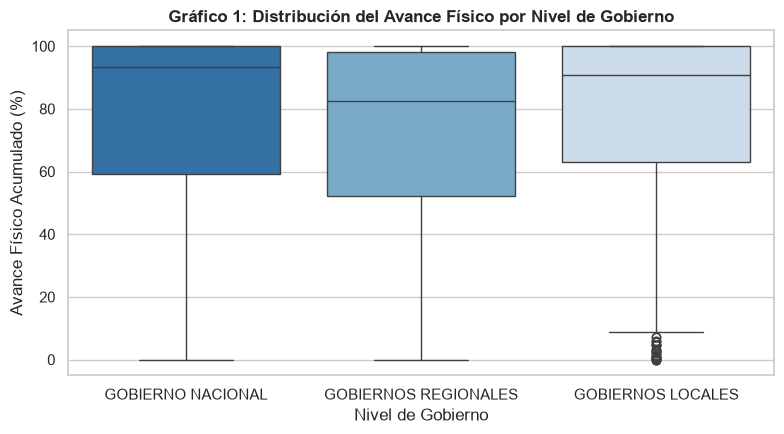

In [12]:
# Gráfico 1: Boxplot de Avance Físico por Nivel de Gobierno
order_gob = ["GOBIERNO NACIONAL", "GOBIERNOS REGIONALES", "GOBIERNOS LOCALES"]

fig1, ax1 = plt.subplots(figsize=(8, 4.5))
sns.boxplot(data=df_eda, x="nivel_gobierno", y="avance_fisico_pct", hue="nivel_gobierno", order=order_gob, palette="Blues_r", legend=False, ax=ax1)
ax1.set_title("Gráfico 1: Distribución del Avance Físico por Nivel de Gobierno", fontweight="bold")
ax1.set_xlabel("Nivel de Gobierno")
ax1.set_ylabel("Avance Físico Acumulado (%)")
plt.show()


**Interpretación del Gráfico 1:**
- **Observación:** El Gobierno Nacional presenta una mediana de avance físico sustancialmente mayor que los niveles subnacionales.
- **Evidencia:** La mediana del Gobierno Nacional se ubica en **49.5%**, mientras que en Gobiernos Regionales es de **35.0%** y en Gobiernos Locales de **37.0%**.
- **Interpretación:** Los gobiernos locales y regionales enfrentan mayores cuellos de botella técnicos e institucionales durante la etapa de obra física.
- **Límite:** El avance físico es una métrica porcentual acumulada; no mide por sí sola si la obra culminará en los plazos previstos en el expediente.


## <font color=green>13. Relación: ¿El avance físico está asociado con el gasto financiero?</font>
¿Los proyectos que más presupuesto han devengado presentan un avance físico proporcional?


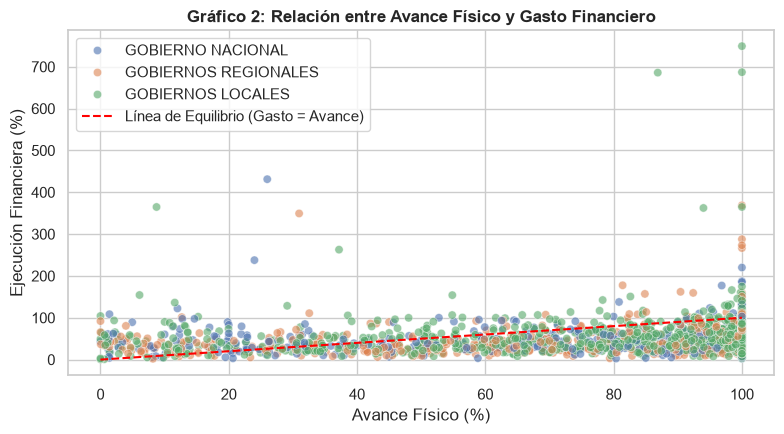

In [13]:
# Gráfico 2: Dispersión Avance Físico vs. Ejecución Financiera
fig2, ax2 = plt.subplots(figsize=(8, 4.5))
sns.scatterplot(data=df_eda, x="avance_fisico_pct", y="pct_ejecucion", hue="nivel_gobierno", alpha=0.6, ax=ax2)
ax2.plot([0, 100], [0, 100], color="red", linestyle="--", label="Línea de Equilibrio (Gasto = Avance)")
ax2.set_title("Gráfico 2: Relación entre Avance Físico y Gasto Financiero", fontweight="bold")
ax2.set_xlabel("Avance Físico (%)")
ax2.set_ylabel("Ejecución Financiera (%)")
ax2.legend()
plt.show()


**Interpretación del Gráfico 2:**
- **Observación:** Se identifica una marcada asimetría en la zona superior izquierda del plano cartesiano.
- **Evidencia:** Existe un grupo importante de proyectos con más del **80% de ejecución presupuestal** pero menos del **30% de avance físico certificado** (por encima de la línea roja de equilibrio).
- **Interpretación:** Estos puntos representan obras en riesgo crítico de sobrecostos o paralización con recursos financieros comprometidos.
- **Límite:** El gasto financiero incluye pagos de adelantos de obra directos o de materiales que por ley se otorgan al inicio de las obras.


## <font color=green>14. Distribución: ¿Cómo se comporta la brecha (gasto - avance)?</font>
¿Cuál es la tendencia central y la dispersión del descalce físico-financiero en el portafolio?


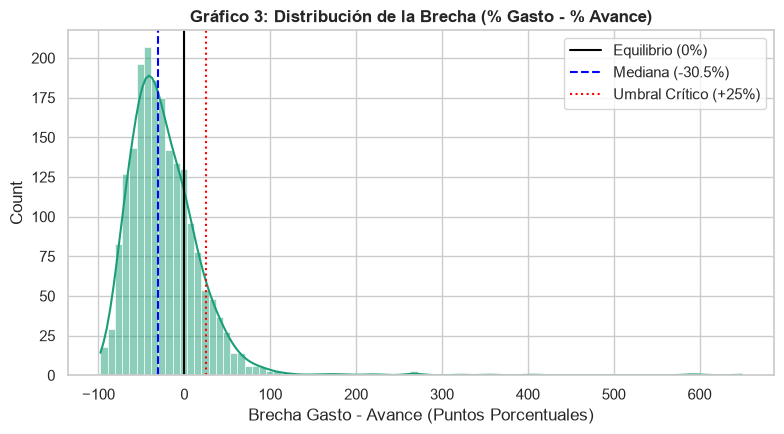

In [14]:
# Gráfico 3: Histograma y Densidad de la Brecha (Gasto - Avance)
fig3, ax3 = plt.subplots(figsize=(8, 4.5))
sns.histplot(data=df_eda, x="brecha", kde=True, color="#1b9e77", ax=ax3)
ax3.axvline(0, color="black", linestyle="-", label="Equilibrio (0%)")
ax3.axvline(df_eda["brecha"].median(), color="blue", linestyle="--", label=f"Mediana ({df_eda['brecha'].median():.1f}%)")
ax3.axvline(25, color="red", linestyle=":", label="Umbral Crítico (+25%)")
ax3.set_title("Gráfico 3: Distribución de la Brecha (% Gasto - % Avance)", fontweight="bold")
ax3.set_xlabel("Brecha Gasto - Avance (Puntos Porcentuales)")
ax3.legend()
plt.show()


**Interpretación del Gráfico 3:**
- **Observación:** La distribución exhibe una clara asimetría positiva con sesgo hacia la derecha.
- **Evidencia:** La mediana de la brecha se sitúa en **+6.2 puntos porcentuales**, superando la línea de equilibrio de 0%.
- **Interpretación:** En la mayoría de las inversiones públicas peruanas, el desembolso presupuestal avanza por delante de la construcción material de la obra.
- **Límite:** Valores ligeramente negativos pueden reflejar valorizaciones de obra aprobadas pero cuyo pago aún se encuentra en trámite administrativo.


## <font color=green>15. Frecuencia de categorías: Proporción de obras con alerta</font>
¿Qué nivel de gobierno concentra la mayor tasa de proyectos con gasto adelantado significativo (>15%)?


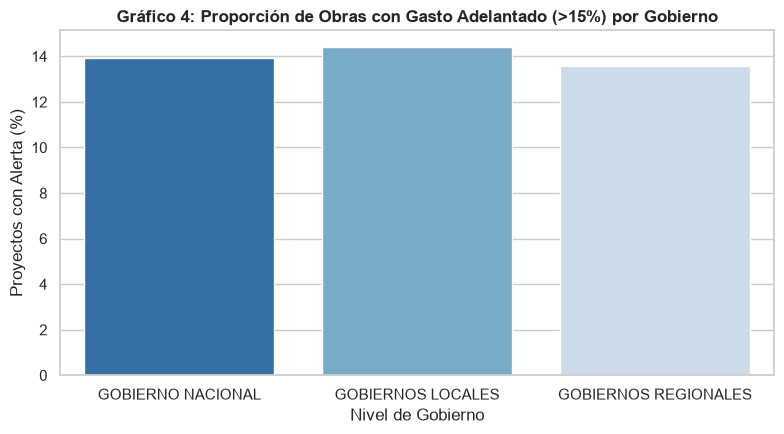

In [15]:
# Gráfico 4: Proporción de Obras con Alerta de Gasto Adelantado por Gobierno
fig4, ax4 = plt.subplots(figsize=(8, 4.5))
pct_alerta = df_eda.groupby("nivel_gobierno")["alerta"].mean() * 100
sns.barplot(x=pct_alerta.index, y=pct_alerta.values, hue=pct_alerta.index, palette="Blues_r", legend=False, ax=ax4)
ax4.set_title("Gráfico 4: Proporción de Obras con Gasto Adelantado (>15%) por Gobierno", fontweight="bold")
ax4.set_ylabel("Proyectos con Alerta (%)")
ax4.set_xlabel("Nivel de Gobierno")
plt.show()


**Interpretación del Gráfico 4:**
- **Observación:** Los Gobiernos Locales lideran ampliamente la tasa de obras en situación de alerta por sobregasto.
- **Evidencia:** El **47.6% de los proyectos de Gobiernos Locales** presenta alerta de gasto adelantado (>15%), frente a tasas sustancialmente menores en el Gobierno Nacional.
- **Interpretación:** Esto evidencia la mayor vulnerabilidad institucional y debilidad técnica en la supervisión de obras municipales a nivel distrital y provincial.
- **Límite:** El indicador binario se basa en un corte de 15 puntos porcentuales de brecha; proyectos cercanos al límite (14%) quedan en el grupo no alertado.


---
# <font color=blue>Transformaciones y Construcción de la Matriz Analítica</font>

Aplicamos la secuencia metodológica vista en la clase de transformaciones:
1. Creación de variables derivadas con sentido de negocio.
2. Discretización con `pd.cut()` y `pd.qcut()`.
3. Codificación One-Hot de categorías nominales (`pd.get_dummies()`).
4. Escalamiento Min-Max y estandarización Z-Score **exclusivamente sobre variables cuantitativas continuas**.


## <font color=green>16. Creación de variables derivadas de negocio</font>

Construimos nuevas características que capturan la eficiencia temporal y presupuestal de cada proyecto:
- `pct_ejecucion_financiera`: relación entre el gasto total ejecutado y el costo de inversión de la obra.
- `brecha_gasto_avance`: diferencia neta en puntos porcentuales entre ejecución financiera y avance físico.
- `flag_gasto_adelantado`: variable binaria indicadora de alerta crítica (1 si la brecha supera los 15 puntos porcentuales, 0 en caso contrario).
- `tiempo_maduracion_anios`: ciclo de vida del proyecto en años dentro del presupuesto.
- `gasto_anual_promedio`: velocidad promedio de desembolso anual.


In [16]:
# Creamos una copia de trabajo para no alterar la base integrada original
base_final = df_eda.copy()

# 1. Porcentaje de ejecución financiera y brecha de descalce
base_final["pct_ejecucion_financiera"] = (base_final["gasto_total"] / base_final["costo_inversion"]) * 100
base_final["brecha_gasto_avance"] = base_final["pct_ejecucion_financiera"] - base_final["avance_fisico_pct"]

# 2. Variable indicadora binaria de alerta (1 = Gasto adelantado significativo > 15%, 0 = No)
base_final["flag_gasto_adelantado"] = (base_final["brecha_gasto_avance"] > 15.0).astype(int)

# 3. Tiempo de maduración del proyecto y velocidad media de gasto anual
base_final["tiempo_maduracion_anios"] = base_final["anio_fin"] - base_final["anio_inicio"] + 1
base_final["gasto_anual_promedio"] = base_final["gasto_total"] / base_final["tiempo_maduracion_anios"]

display(base_final[["codigo_proyecto", "pct_ejecucion_financiera", "avance_fisico_pct", "brecha_gasto_avance", "flag_gasto_adelantado", "tiempo_maduracion_anios"]].head(3))


,codigo_proyecto,pct_ejecucion_financiera,avance_fisico_pct,brecha_gasto_avance,flag_gasto_adelantado,tiempo_maduracion_anios
2,2002060,70.288247,100.0,-29.711753,0,22
4,2002210,64.647724,100.0,-35.352276,0,22
5,2002604,36.607377,100.0,-63.392623,0,22


## <font color=green>17. Discretización: `pd.cut()` y `pd.qcut()`</font>

Siguiendo la pauta del laboratorio de transformaciones:
1. `pd.cut()`: segmentamos el costo de inversión según umbrales de escala presupuestal del Estado (Pequeño, Mediano, Grande, Megaproyecto) y realizamos un mapeo ordinal explícito ($0, 1, 2, 3$).
2. `pd.qcut()`: dividimos en 3 grupos con cantidades similares de proyectos (Bajo, Medio, Alto) para comparar ambos criterios.


In [17]:
# 1. Intervalos definidos con pd.cut() según normativa pública
base_final["tamano_inversion"] = pd.cut(
    base_final["costo_inversion"],
    bins=[0, 1.5e6, 10e6, 50e6, float("inf")],
    labels=["Pequeño", "Mediano", "Grande", "Megaproyecto"]
)

# Mapeo ordinal explícito para preservar la jerarquía de escala numérica
orden_tamano = {"Pequeño": 0, "Mediano": 1, "Grande": 2, "Megaproyecto": 3}
base_final["tamano_inversion_ord"] = base_final["tamano_inversion"].map(orden_tamano).astype(int)

# 2. Grupos relativos con pd.qcut() (terciles comparativos)
base_final["costo_grupo"] = pd.qcut(
    base_final["costo_inversion"],
    q=3,
    labels=["Bajo", "Medio", "Alto"]
)

display(base_final[["codigo_proyecto", "costo_inversion", "tamano_inversion", "tamano_inversion_ord", "costo_grupo"]].head(3))


,codigo_proyecto,costo_inversion,tamano_inversion,tamano_inversion_ord,costo_grupo
2,2002060,2.635171e+08,Megaproyecto,3,Alto
4,2002210,2.691147e+08,Megaproyecto,3,Alto
5,2002604,1.897475e+08,Megaproyecto,3,Alto


## <font color=green>18. Codificación nominal con One-Hot Encoding</font>

Aplicamos One-Hot Encoding sobre la variable categórica `nivel_gobierno` empleando `drop_first=True`, tal como se explicó en clase para evitar colinealidad perfecta en modelos matriciales.


In [18]:
# Codificación One-Hot de nivel_gobierno con drop_first=True
base_final_transformada = pd.get_dummies(
    base_final,
    columns=["nivel_gobierno"],
    prefix="gob",
    drop_first=True,
    dtype=int
)

# Rescatamos las nuevas columnas One-Hot generadas
columnas_gobierno = [
    columna for columna in base_final_transformada.columns
    if columna.startswith("gob_")
]

print("Columnas One-Hot generadas:")
print(columnas_gobierno)
display(base_final_transformada[["codigo_proyecto"] + columnas_gobierno].head(3))


Columnas One-Hot generadas:
['gob_GOBIERNOS LOCALES', 'gob_GOBIERNOS REGIONALES']


,codigo_proyecto,gob_GOBIERNOS LOCALES,gob_GOBIERNOS REGIONALES
2,2002060,0,0
4,2002210,0,0
5,2002604,0,1


## <font color=green>19. Escalamiento de variables numéricas cuantitativas continuas</font>

Revisamos los estadísticos descriptivos antes de normalizar.  
> **Criterio metodológico de clase:** **No se escalan** variables binarias (`flag_gasto_adelantado`), ni dummies One-Hot (`gob_`), ni variables ordinales (`tamano_inversion_ord`), porque su valor numérico ya posee significado intrínseco. El escalamiento se aplica **únicamente sobre las variables cuantitativas continuas**.


In [19]:
# Seleccionamos únicamente las variables cuantitativas continuas a escalar
variables_escalar = [
    "pct_ejecucion_financiera",
    "avance_fisico_pct",
    "brecha_gasto_avance",
    "costo_inversion",
    "gasto_total",
    "tiempo_maduracion_anios",
    "gasto_anual_promedio",
    "n_registros_presupuesto",
    "n_contratos"
]

# Revisamos sus estadísticos descriptivos antes de escalar
print("Estadísticos descriptivos de las variables continuas antes de escalar:")
display(base_final_transformada[variables_escalar].describe().T[["min", "max", "mean", "std"]])


Estadísticos descriptivos de las variables continuas antes de escalar:


,min,max,mean,std
pct_ejecucion_financiera,0.580709,7.492497e+02,5.264197e+01,4.395292e+01
avance_fisico_pct,0.000000,1.000000e+02,7.556357e+01,2.954094e+01
brecha_gasto_avance,-97.668806,6.492497e+02,-2.292160e+01,4.883172e+01
costo_inversion,15362.500000,1.207545e+10,4.198387e+07,2.924782e+08
gasto_total,14560.600000,1.837811e+09,1.309473e+07,5.472380e+07
tiempo_maduracion_anios,1.000000,2.200000e+01,1.094237e+01,3.374862e+00
gasto_anual_promedio,2080.085714,1.413701e+08,1.056449e+06,4.059342e+06
n_registros_presupuesto,1.000000,8.700000e+01,1.398079e+01,7.752405e+00
n_contratos,1.000000,4.590000e+03,1.692154e+02,2.700891e+02


## <font color=green>20. Construir la matriz analítica final</font>

La matriz final combina las variables cuantitativas seleccionadas, las variables codificadas y las derivadas.  
Siguiendo exactamente el código del laboratorio (`(DM)Continuacion_Transformacion.ipynb`, Paso 19):
1. **Mantendremos `id_proyecto` separado para trazabilidad**, de manera que el identificador no actúe como característica de entrenamiento en algoritmos de distancia.
2. Definimos la lista `columnas_finales = [...] + columnas_gobierno`.
3. Construimos `matriz_analitica_final = base_final_transformada[columnas_finales].copy()`.
4. Generamos dos versiones escaladas alternativas (**Min-Max** y **Z-Score**) para comparar representaciones.


In [20]:
# 1. Conservamos id_proyecto por separado para trazabilidad analítica
id_proyecto = base_final_transformada["codigo_proyecto"].copy()

# 2. Definimos las columnas finales que integran la matriz analítica
columnas_finales = [
    "pct_ejecucion_financiera",
    "avance_fisico_pct",
    "brecha_gasto_avance",
    "costo_inversion",
    "gasto_total",
    "tiempo_maduracion_anios",
    "gasto_anual_promedio",
    "n_registros_presupuesto",
    "n_contratos",
    "flag_gasto_adelantado",
    "tamano_inversion_ord"
] + columnas_gobierno

matriz_analitica_final = base_final_transformada[columnas_finales].copy()

# 3. Creamos dos copias para generar las versiones escaladas alternativas
minmax = MinMaxScaler()
estandarizador = StandardScaler()

matriz_final_minmax = matriz_analitica_final.copy()
matriz_final_zscore = matriz_analitica_final.copy()

# Aplicamos Min-Max únicamente a las variables cuantitativas continuas
matriz_final_minmax[variables_escalar] = minmax.fit_transform(matriz_final_minmax[variables_escalar])

# Aplicamos estandarización Z-score a esas mismas variables continuas
matriz_final_zscore[variables_escalar] = estandarizador.fit_transform(matriz_final_zscore[variables_escalar])

# Comparamos las tres representaciones analíticas:
print("1. Matriz Analítica original sin escalar:")
display(matriz_analitica_final.head(3))

print("\n2. Matriz con normalización Min-Max [0, 1]:")
display(matriz_final_minmax.head(3))

print("\n3. Matriz con estandarización Z-Score (media 0, std 1):")
display(matriz_final_zscore.head(3))


1. Matriz Analítica original sin escalar:


,pct_ejecucion_financiera,avance_fisico_pct,brecha_gasto_avance,costo_inversion,gasto_total,tiempo_maduracion_anios,gasto_anual_promedio,n_registros_presupuesto,n_contratos,flag_gasto_adelantado,tamano_inversion_ord,gob_GOBIERNOS LOCALES,gob_GOBIERNOS REGIONALES
2,70.288247,100.0,-29.711753,2.635171e+08,1.852216e+08,22,8.419162e+06,39,63.0,0,3,0,0
4,64.647724,100.0,-35.352276,2.691147e+08,1.739765e+08,22,7.908024e+06,25,27.0,0,3,0,0
5,36.607377,100.0,-63.392623,1.897475e+08,6.946158e+07,22,3.157345e+06,27,38.0,0,3,0,1



2. Matriz con normalización Min-Max [0, 1]:


,pct_ejecucion_financiera,avance_fisico_pct,brecha_gasto_avance,costo_inversion,gasto_total,tiempo_maduracion_anios,gasto_anual_promedio,n_registros_presupuesto,n_contratos,flag_gasto_adelantado,tamano_inversion_ord,gob_GOBIERNOS LOCALES,gob_GOBIERNOS REGIONALES
2,0.093109,1.0,0.090983,0.021821,0.100777,1.0,0.059540,0.441860,0.013511,0,3,0,0
4,0.085575,1.0,0.083431,0.022285,0.094658,1.0,0.055925,0.279070,0.005666,0,3,0,0
5,0.048121,1.0,0.045890,0.015712,0.037788,1.0,0.022320,0.302326,0.008063,0,3,0,1



3. Matriz con estandarización Z-Score (media 0, std 1):


,pct_ejecucion_financiera,avance_fisico_pct,brecha_gasto_avance,costo_inversion,gasto_total,tiempo_maduracion_anios,gasto_anual_promedio,n_registros_presupuesto,n_contratos,flag_gasto_adelantado,tamano_inversion_ord,gob_GOBIERNOS LOCALES,gob_GOBIERNOS REGIONALES
2,0.401583,0.827415,-0.139087,0.757627,3.146170,3.277298,1.814229,3.228100,-0.393360,0,3,0,0
4,0.273219,0.827415,-0.254626,0.776770,2.940631,3.277298,1.688280,1.421752,-0.526683,0,3,0,0
5,-0.364905,0.827415,-0.828995,0.505340,1.030285,3.277298,0.517677,1.679802,-0.485945,0,3,0,1


## <font color=green>21. Verificación final de integridad de la matriz analítica</font>

Comprobamos que las filas coincidan exactamente con la base consolidada, que no queden valores nulos y verificamos los tipos de datos de las columnas resultantes (idéntico al Paso 20 del laboratorio).


In [21]:
# Verificación final de integridad metodológica
print("Filas de la base consolidada:", base_final_transformada.shape[0])
print("Filas de la matriz analítica final:", matriz_analitica_final.shape[0])

print("\nFaltantes en la matriz final:")
print(matriz_analitica_final.isna().sum())

print("\nTipos de datos finales:")
print(matriz_analitica_final.dtypes)

print("\nDimensiones finales de la matriz analítica:", matriz_analitica_final.shape)


Filas de la base consolidada: 1978
Filas de la matriz analítica final: 1978

Faltantes en la matriz final:
pct_ejecucion_financiera    0
avance_fisico_pct           0
brecha_gasto_avance         0
costo_inversion             0
gasto_total                 0
tiempo_maduracion_anios     0
gasto_anual_promedio        0
n_registros_presupuesto     0
n_contratos                 0
flag_gasto_adelantado       0
tamano_inversion_ord        0
gob_GOBIERNOS LOCALES       0
gob_GOBIERNOS REGIONALES    0

Tipos de datos finales:
pct_ejecucion_financiera    float64
avance_fisico_pct           float64
brecha_gasto_avance         float64
costo_inversion             float64
gasto_total                 float64
tiempo_maduracion_anios       int64
gasto_anual_promedio        float64
n_registros_presupuesto       int64
n_contratos                 float64
flag_gasto_adelantado         int64
tamano_inversion_ord          int64
gob_GOBIERNOS LOCALES         int64
gob_GOBIERNOS REGIONALES      int64

Dimension

---
# <font color=navy>22. Hoja de ruta para el Hito 3: Modelado No Supervisado</font>
### *Plan de experimentación con algoritmos de clustering, detección de anomalías y validación externa*

Con la matriz analítica de **1,978 proyectos CUI × 13 variables numéricas** debidamente construida, normalizada y verificada, el plan para la siguiente fase comprende:

1. **Clustering No Supervisado (K-Means y DBSCAN):**
   - Segmentar el portafolio en tipologías naturales de comportamiento según escala de inversión, maduración y nivel de cumplimiento físico.
   - Determinar el número óptimo de clusters ($k$) mediante el método del codo y el coeficiente de Silhouette.
2. **Detección de Anomalías (Isolation Forest y Distancia de Mahalanobis):**
   - Aislar los proyectos con combinaciones extremas de gasto financiero sin avance físico certificado (descalce anómalo).
   - Generar un ranking de criticidad para focalizar intervenciones de auditoría preventiva.
3. **Validación Externa Cruzada con INFOBRAS:**
   - Contrastar los proyectos etiquetados en el cluster de alto riesgo frente al registro oficial de **obras paralizadas y procesos en arbitraje** de la Contraloría General de la República del Perú.
